In [2]:
import os
import copy
import time

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [4]:
dataset_path = "dataset"

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")

In [5]:
# Аугментация

train_transform = transforms.Compose([

    transforms.RandomRotation(360),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.1,0.1),
        scale=(0.9,1.1)
    ),

    transforms.ColorJitter(
        brightness=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

val_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [6]:
# Загрузка датасета с проверкой классов
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_transform
)

print(train_dataset.classes)

['1', '10', '2', '5']


In [7]:
train_loader = DataLoader(

    train_dataset,

    batch_size=8,

    shuffle=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=8,

    shuffle=False

)

In [24]:
# Создаем модель без предобученных весов
model = models.mobilenet_v3_small(weights=None)

# путь к скачанному файлу
weights_path = r"C:/Users/Gwynbleidd/Downloads/models/mobilenet_v3_small-047dcff4.pth"

# Загружаем веса
state_dict = torch.load(weights_path, map_location='cpu')

# Применяем веса к модели
model.load_state_dict(state_dict)

# Переводим модель в режим оценки
model.eval()

print("Модель успешно загружена!")

Модель успешно загружена!


In [25]:
# Меняем последний слой - у модели было 1000 класов, которые мы меняем на 4

model.classifier[3] = nn.Linear(

    model.classifier[3].in_features,

    4

)

model = model.to(device)

In [26]:
# Loss и Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.0001

)

In [27]:
# ------------ Обучение --------------

num_epochs = 30

best_acc = 0

train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):

    print(f"\nЭпоха {epoch+1}/{num_epochs}")

    #################################
    # TRAIN
    #################################

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    #################################
    # VALIDATION
    #################################

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)

    val_acc = correct / total

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Acc : {train_acc:.4f}")

    print(f"Val Loss  : {val_loss:.4f}")

    print(f"Val Acc   : {val_acc:.4f}")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(

            model.state_dict(),

            "coin_model.pth"

        )

print("\nМодель сохранена.")


Эпоха 1/30
Train Loss: 1.3399
Train Acc : 0.3667
Val Loss  : 1.4325
Val Acc   : 0.2353

Эпоха 2/30
Train Loss: 1.2557
Train Acc : 0.4167
Val Loss  : 1.2895
Val Acc   : 0.2941

Эпоха 3/30
Train Loss: 1.1326
Train Acc : 0.5667
Val Loss  : 1.1922
Val Acc   : 0.3529

Эпоха 4/30
Train Loss: 1.0794
Train Acc : 0.6500
Val Loss  : 1.1168
Val Acc   : 0.3529

Эпоха 5/30
Train Loss: 0.9621
Train Acc : 0.7500
Val Loss  : 1.0722
Val Acc   : 0.2941

Эпоха 6/30
Train Loss: 0.8107
Train Acc : 0.7833
Val Loss  : 1.0260
Val Acc   : 0.2941

Эпоха 7/30
Train Loss: 0.6972
Train Acc : 0.8333
Val Loss  : 0.9885
Val Acc   : 0.3529

Эпоха 8/30
Train Loss: 0.5610
Train Acc : 0.8667
Val Loss  : 0.9557
Val Acc   : 0.3529

Эпоха 9/30
Train Loss: 0.5627
Train Acc : 0.8833
Val Loss  : 0.9048
Val Acc   : 0.3529

Эпоха 10/30
Train Loss: 0.5024
Train Acc : 0.8667
Val Loss  : 0.8464
Val Acc   : 0.4706

Эпоха 11/30
Train Loss: 0.4730
Train Acc : 0.8000
Val Loss  : 0.7862
Val Acc   : 0.4118

Эпоха 12/30
Train Loss: 0.494

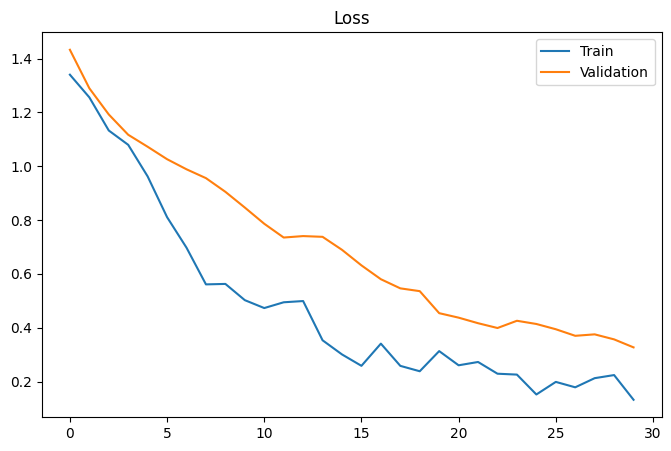

In [28]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_history,label="Train")

plt.plot(val_loss_history,label="Validation")

plt.legend()

plt.title("Loss")

plt.show()

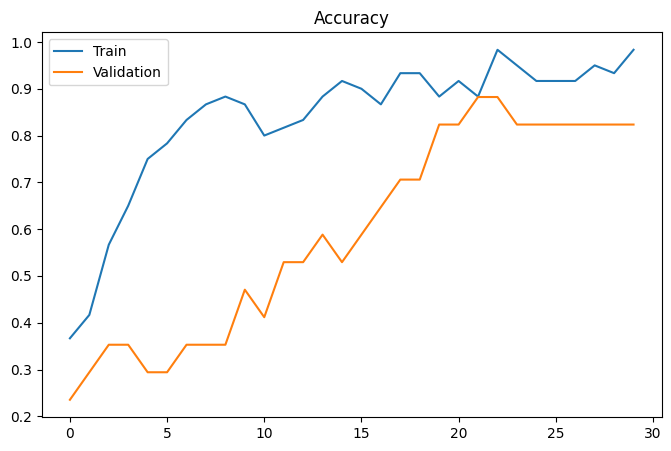

In [29]:
plt.figure(figsize=(8,5))

plt.plot(train_acc_history,label="Train")

plt.plot(val_acc_history,label="Validation")

plt.legend()

plt.title("Accuracy")

plt.show()